# Развертывание ML-моделей: диф. зачет

### Шаг 1. Постановка цели. Выберите самую простую и понимаемую бизнес-задачу (например, для расчета складских запасов магазина достаточно трех таблиц — товар, склад, заказ). Выберите одну бизнес-метрику. Перепишите бизнес-требования на язык ML-проектирования.

Для визуализации цели я взял своб работу по хакатону и решил её правильно упаковать.

- Бизнес-задача: Удержание студентов на онлайн-платформе (EdTech). Платформа теряет деньги, когда студенты бросают курсы на середине. Нужно находить тех, кто собирается отвалиться, до того, как они это сделают, чтобы кураторы успели вмешаться.

- Бизнес-метрика: Повышение Retention Rate (процента удержания) и ROI (возврат инвестиций) от работы отдела кураторов.

- Язык ML-проектирования: Задача Survival Analysis (Анализ выживаемости). Необходимо спрогнозировать риск (Hazard Score) оттока студента в зависимости от времени, проведенного на платформе,

### Шаг 2. Выбор уровня сложности реализуемой системы. 

1. Предыстория    
Школа онлайн обучения несет убытки из-за оттока студентов, который сложно предсказать. Текущий подход работы (когда студент уже перестал заходить) неэффективен. Кураторам нужен инструмент, который подсвечивает студентов из зоны риска заранее, чтобы с ними можно проводить корректирующие мероприятия.

2. Ценностное предложение   
Продукт автоматически рассчитывает hazard_score для каждого студента на основе его данных в процессе обучения. Это позволяет кураторам тратить время только на тех, кому нужна помощь прямо сейчас, экономя ресурсы бизнеса.

3. Цели
- Разработать пайплайн валидации и обработки исторических данных студентов.
- Обучить модель выживаемости (Survival Model).
- Настроить автоматическое версионирование моделей и метрик.
- Развернуть API для инференса в реальном времени.

4. Решение
Разрабатывается MLOps-платформа Уровня 2.
Фичи: Пайплайн на Dagster, трекинг экспериментов в MLflow, API на FastAPI, мониторинг через Prometheus/Grafana. Модель прогнозирования — Cox Proportional Hazards (CoxPH).    
Интеграции: Чтение фичей из PostgreSQL, отдача прогнозов через REST API.     
Ограничения/Что не входит: Система только выдает скоринг риска. Автоматическая рассылка писем студентам в скоуп не входит (остается на стороне CRM заказчика).     
Заявленный уровень зрелости: Уровень 2 (Полная автоматизация, оркестрация, CI/CD, трекинг и мониторинг).    

5. Осуществимость
Решение полностью осуществимо. В наличии имеются вычислительные ресурсы (выделенный сервер, хоть и в минимальном виде, так как оперативной памяти ровно впритык, работает пока данное решение тяжело) и необходимые компетенции для развертывания микросервисной архитектуры (Docker Compose).

6. Данные
Обучающий набор: Исторические данные выгрузок из LMS (активность, сдача ДЗ, коммуникация в чатах).
Прод набор: Потоковые логи действий студентов, поступающие через Data Gateway.
Разметка: Не требует ручной разметки. Класс события (отток/не отток) и длительность (дни) формируются автоматически из логов базы данных LMS, так как эти данные легко логгируются.

7. Метрики
Бизнес: Увеличение LTV (Lifetime Value) студента, конверсия "спасенных" студентов.    
ML: Concordance Index (C-index) для оценки качества ранжирования рисков моделью CoxPH.

8. Оценка качества модели
Офлайн-метрика: C-index на тестовой отложенной выборке (в процессе работы пайплайна).    
Онлайн-метрика: A/B тестирование в продакшене (Сравниваем процент отвала в группе, где кураторы действуют по ML-подсказкам, с контрольной группой без ML).

9. Подбор модели
Итеративный подход: старт с базовой интерпретируемой модели (CoxPH) для обеспечения прозрачности предсказаний (какая фича сильнее всего влияет на риск). В последующих итерациях — переход на ансамбли (Random Survival Forests/CatBoost) при необходимости повышения точности.

10. Инференс
Обработка сырых данных и переобучение производятся батчами (раз в сутки). Инференс - в реальном времени (REST API).    
Жизненный цикл модели: Архитектура системы Уровня 2 спроектирована с учетом строгого регламента обновления.    
При выявлении деградации метрик (Data Drift или падение C-index) старая модель выводится из эксплуатации.    
Процесс вывода подразумевает переключение трафика на новую модель через A/B тестирование.    
Примечание к текущей реализации: На данном этапе развития продукта (в развернутом на сервере контуре) реализована инфраструктурная база.     
Вывод из эксплуатации и подмена артефакта новой модели происходят через оркестратор и рестарт FastAPI-контейнера.  
Автоматизация роутинга трафика не реализована.    

11. Обратная связь
Источники: Факт ухода студента (True Label) собирается в БД с задержкой, сопоставляется с выданным ранее прогнозом.    
Использование MDD: Да. Мониторинг Data Quality, Latency и бизнес-метрики будут использоваться для запуска переобучения.

12. Управление проектом
Разработчики: 1 (больше всё равно нет).
Результаты: Развернутая система в облаке, код в репозитории с CI/CD.
Сроки: Дедлайн - 31 мая 2026.

### Шаг 3. Создание ML-системы
В файле docker-compose.yml описан полный контур Уровня 2, состоящий из 5 изолированных микросервисов, объединенных внутренней сетью backend_net.
При этом реализация не совсем полная, на текущий момент Prometheus и Dagster не связаны между собой, так как в случае падения метрик не реализовано переобучение в Dagster. Но это можно реализовать отдельно, вся инфраструктура для этого есть. 

- Feature Store (PostgreSQL): Хранилище сырых данных и признаков.

- Orchestrator (Dagster): Управляет оркестрацией, запускает проверки Data Quality (EvidentlyAI) и инициирует обучение.

- Model Registry & Tracking (MLflow): Версионирует гиперпараметры модели CoxPH, сохраняет артефакты (.pkl) и метрики (c_index).

- Serving API (FastAPI): Загружает обученную модель из общего volume и отдает инференс (hazard score) по HTTP.

- Monitoring (Prometheus + Grafana): Собирает системные и бизнес-метрики в реальном времени.

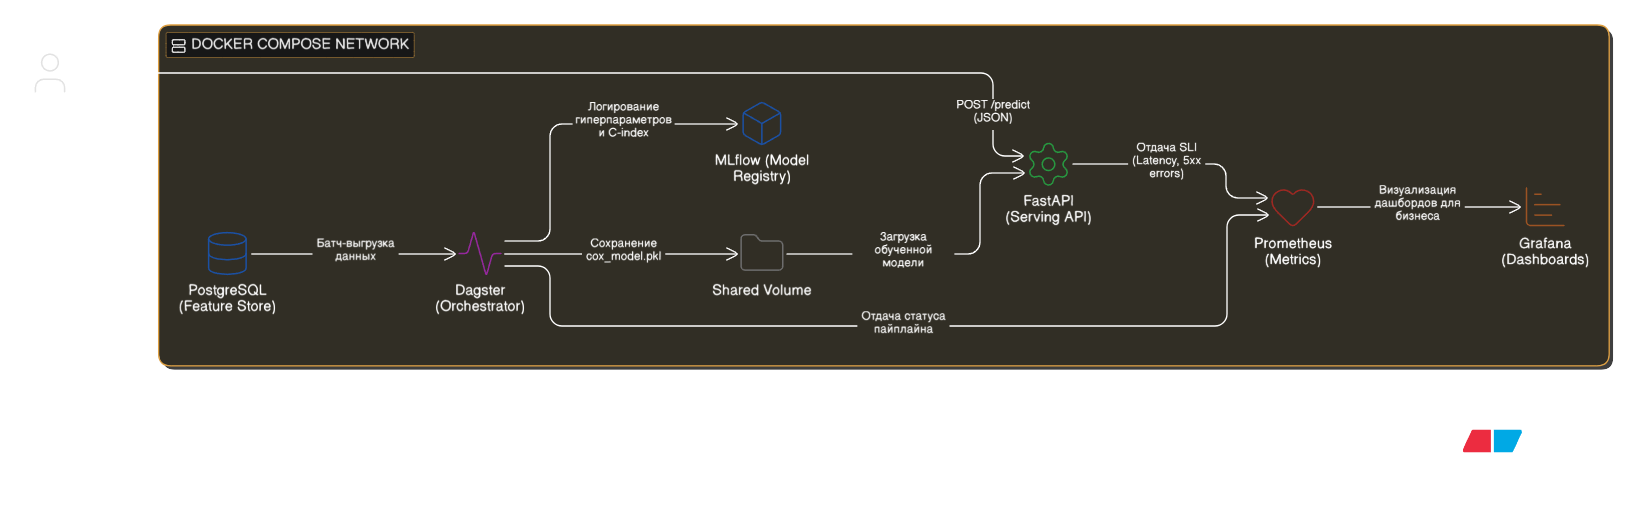

Управление инфраструктурой (IaC):    
Развертывание всей ML-системы осуществляется одной командой: docker compose up -d.    
Деинсталляция инфраструктуры: Для полного удаления системы, включая очистку сетей и хранилищ (volumes) после завершения работы, предусмотрена штатная команда очистки:
docker compose down -v

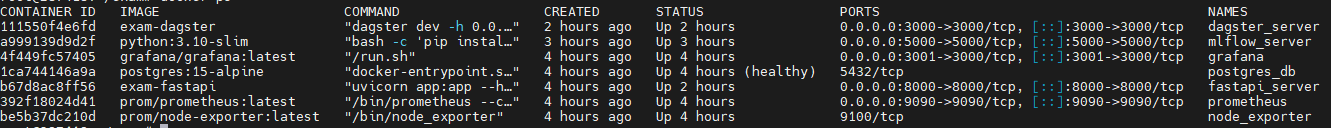

## Шаг 4. Управление рисками.

Для обеспечения надежности MLOps-инфраструктуры Уровня 2 я внедрил метрики SLI и целевые показатели SLO, разделив их на три требуемых уровня мониторинга:

1. Технический уровень (Инфраструктура и API)      
SLI (Latency API): Среднее время ответа микросервиса FastAPI на эндпоинте /predict.    
SLO: 95% запросов обрабатываются быстрее 300 мс.    
SLI (Ресурсы): Потребление RAM контейнером Dagster во время обучения модели.    
SLO: Потребление не должно превышать 80% от доступной памяти (до 3200 МБ из 4 ГБ), чтобы избежать ошибки OOM. *На самом деле пришлось расширить пул памяти до 8гб иначе система задыхалась и падала на сборке контейнеров через раз. Для продакшена можно будет вернуться к старым 4гб, но лучше не нужно.*   

2. Модельный уровень (Качество ML)     
SLI (Метрика качества): Concordance Index (C-index) обученной модели CoxPH на тестовой выборке (считается в MLflow).    
SLO: C-index должен быть >0.75. Если ниже - модель не деплоится.    
SLI (Data Drift): Процент признаков с изменившимся распределением (через отчет EvidentlyAI).    
SLO: Менее 20% дрейфующих признаков во входящем батче данных.    

3. Бизнес-уровень (Продуктовые метрики)    
SLI (Удержание студентов): Конверсия удержания (Retention) среди тех студентов, которых модель отметила высоким риском (Hazard Score > 0.8), и с которыми связался куратор.     
SLO: Удержание должно составить не менее 15% от группы риска.    
SLI (Экономика): Возврат инвестиций (ROI) от внедрения ML-инструмента.    
SLO: ROI > 120% по итогам учебного полугодия.    

## Шаг 5. Принятие решений по Metrics Driven Development.

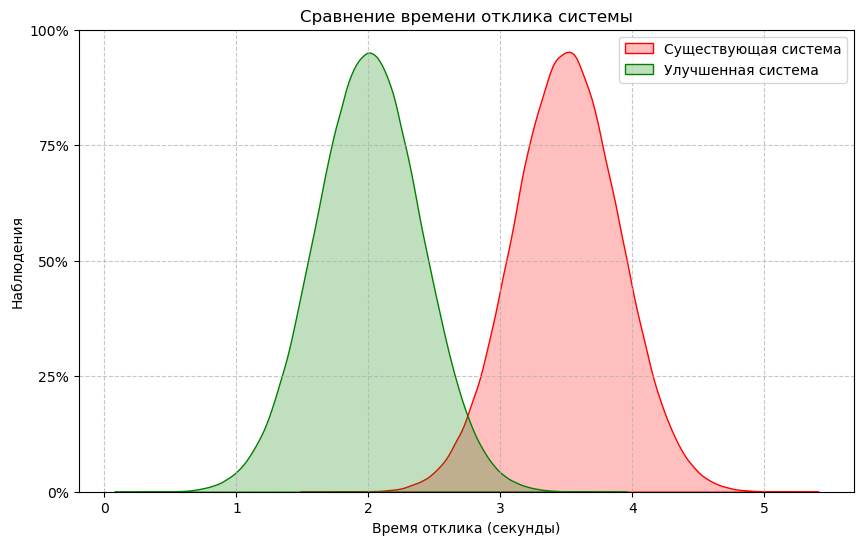

Результаты стат.анализа:
T-statistic: 1875.08
P-value: 0.0


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

np.random.seed(42)
plt.figure(figsize=(10, 6))
existing_system_responses = np.random.normal(loc=3.5, scale=0.4, size=500000)
improved_system_responses = np.random.normal(loc=2.0, scale=0.4, size=500000)
sns.kdeplot(
    existing_system_responses, label="Существующая система", fill=True, color="red"
)
sns.kdeplot(
    improved_system_responses, label="Улучшенная система", fill=True, color="green"
)
plt.title("Сравнение времени отклика системы")
plt.xlabel("Время отклика (секунды)")
plt.ylabel("Наблюдения")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
ax = plt.gca()
ymin, ymax = ax.get_ylim()
num_ticks = 5
new_yticks = np.linspace(ymin, ymax, num_ticks)
new_yticklabels = [
    f"{int((tick / ymax) * 100)}%" if ymax != 0 else "0%" for tick in new_yticks
]
ax.set_yticks(new_yticks)
ax.set_yticklabels(new_yticklabels)
plt.show()

t_stat, p_value = stats.ttest_ind(
    existing_system_responses, 
    improved_system_responses, 
    alternative='greater'
)

print("Результаты стат.анализа:")
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value}")


Документирование архитектурного решения выполнено в формате **ADR (Architecture Decision Record)**.

---    
**Title:** ADR-001: Переход на улучшенную архитектуру инференса API   
**Status:** Принято (Accepted)   
**Date:** 31 мая 2026   

#### 1. Context (Контекст)
Текущая реализация синхронного инференса (Существующая система) при высоких нагрузках показывает среднее время отклика около 3.5 секунд. Это приводит к риску срабатывания таймаутов на стороне клиентских систем. Разработан прототип оптимизированной архитектуры (Улучшенная система). Необходимо принять data-driven решение о целесообразности миграции продакшена на новую архитектуру.

#### 2. Decision (Решение)   
Для принятия решения применен метод MDD с использованием A/B тестирования метрик производительности. 

**Сформулированы гипотезы:**
* $H_0$ (Нулевая гипотеза): Среднее время отклика существующей и улучшенной систем одинаково. Переход не имеет смысла.
* $H_1$ (Альтернативная гипотеза): Среднее время отклика улучшенной системы статистически значимо меньше, чем у существующей.

**Параметры теста:**
* **Тест:** Односторонний T-критерий Стьюдента для независимых выборок (Welch's t-test).
* **Уровень значимости:** $\alpha = 0.05$.

**Результаты тестирования:**
* Полученное значение $p-value \approx 0.0$. 
* Так как $p-value < \alpha$, мы уверенно **отвергаем нулевую гипотезу ($H_0$)**.

**Утвержденное решение:**
Разница во времени отклика не является случайностью. Принято решение перевести FastAPI-сервис на новую архитектуру для выполнения установленных требований SLO (минимизация Latency).

#### 3. Consequences (Последствия)
* **Позитивные:** Снижение среднего времени отклика до 2.0 секунд, повышение отказоустойчивости системы, улучшение пользовательского опыта кураторов.
* **Негативные/Затраты:** Потребуется выделение ресурсов инженера на внедрение новой системы.
---